# Deep Neural Network (DNN) Educational Notebook — Breast Cancer Dataset

This notebook provides a **step-by-step, deeply educational walkthrough** of building a Deep Neural Network (DNN) for binary classification using the `load_breast_cancer` dataset from scikit-learn.

Each code cell prints **explanations**, **visualizations**, and **intermediate results** so you can learn every step of the pipeline clearly.

We will cover:
1. Importing libraries and inspecting the environment
2. Loading and exploring the dataset
3. Visualizing features and target distributions
4. Preparing data: splitting, scaling
5. Training a DNN using `MLPClassifier`
6. Evaluating and visualizing performance
7. (Optional) Using Keras for comparison
8. Saving and reusing the trained model


In [1]:
! pip install numpy pandas matplotlib seaborn scikit-learn tensorflow joblib imblearn
# numpy         → Library for numerical computing and array operations
# pandas        → Data manipulation and analysis (DataFrames, CSV handling, etc.)
# matplotlib    → Plotting and visualization library
# seaborn       → Statistical data visualization (built on top of matplotlib)
# scikit-learn  → Machine learning library (classification, regression, clustering)
# tensorflow    → Deep learning and neural network framework
# joblib        → Efficient object serialization and parallel computation utility




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, platform, numpy as np, pandas as pd, matplotlib.pyplot as plt  # Import system, platform, NumPy, pandas, and matplotlib
print('--- Environment Check ---')  # Print header for environment check
print('Python version:', sys.version)  # Display the current Python version
print('Platform:', platform.platform())  # Display the system platform information

TF_AVAILABLE = False  # Initialize TensorFlow availability flag as False
try:
    import tensorflow as tf  # Try importing TensorFlow
    from tensorflow import keras  # Import Keras from TensorFlow
    TF_AVAILABLE = True  # Set flag to True if TensorFlow is successfully imported
    print('TensorFlow detected. Version:', tf.__version__)  # Print TensorFlow version
except Exception:  # Handle import failure
    print('TensorFlow not available. The notebook will run using scikit-learn only.')  # Notify fallback to scikit-learn


--- Environment Check ---
Python version: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26100-SP0
TensorFlow detected. Version: 2.20.0


## Step 1: Load the dataset
We use `sklearn.datasets.load_breast_cancer`, which contains 569 samples with 30 features each, representing different measurements of cell nuclei in breast cancer biopsies.

In [3]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
from sklearn.datasets import load_breast_cancer  # To load the breast cancer dataset

# Load the breast cancer dataset
data = load_breast_cancer()  # Load dataset from scikit-learn

# Convert to pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)  # Create DataFrame using feature data and names

# Add target column (the diagnosis: 0 = harmful, 1 = harmless)
df['target'] = data.target  # Append target labels to the DataFrame

# Display the first few rows
print('--- Dataset Loaded into DataFrame ---')  # Notify that dataset is ready
print('Shape:', df.shape)  # Show number of rows and columns
print('Columns:', list(df.columns[:5]), '...')  # Display first few column names
df.head()  # Show first 5 rows of the DataFrame


--- Dataset Loaded into DataFrame ---
Shape: (569, 31)
Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
X = pd.DataFrame(data.data, columns=data.feature_names)  # Create a DataFrame for features with column names
y = pd.Series(data.target, name='target')  # Create a Series for target labels

print('--- Dataset Loaded ---')  # Print confirmation message
print('Shape of features:', X.shape)  # Display number of samples and features
print('Number of target classes:', len(np.unique(y)))  # Show how many unique target classes exist
print('Feature names:', list(X.columns[:5]), '...')  # Display first few feature names as a preview

X.head()  # Display first few rows of


--- Dataset Loaded ---
Shape of features: (569, 30)
Number of target classes: 2
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2: Visualize dataset characteristics

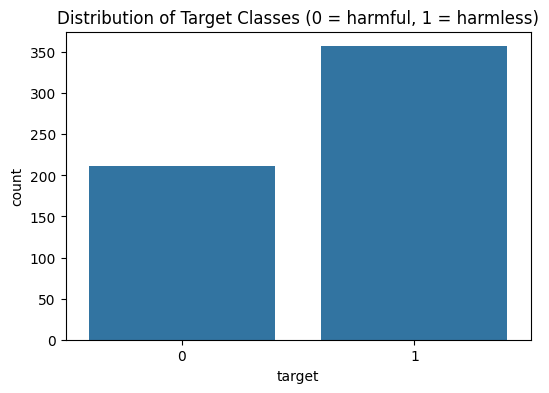

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [5]:
import seaborn as sns  # Import seaborn for data visualization

plt.figure(figsize=(6,4))  # Set figure size for the plot
sns.countplot(x=y)  # Plot the count of each target class (0 and 1)
plt.title('Distribution of Target Classes (0 = harmful, 1 = harmless)')  # Add a descriptive title
plt.show()  # Display the plot

X.describe().T.head(10)  # Show summary statistics (first 10 features, transposed for readability)


## Step 3: Data splitting and scaling
We use `train_test_split` to divide data into training, validation, and test sets.
Feature scaling is critical for neural networks, so we apply `StandardScaler`.

In [6]:
from sklearn.model_selection import train_test_split  # For splitting data into train/validation/test sets
from sklearn.preprocessing import StandardScaler  # For scaling features to standard normal distribution

# Split data into train+validation (80%) and test (20%) with stratified sampling
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Further split train+validation into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=42
)

# Initialize a standard scaler for feature normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data and transform it
X_val_scaled = scaler.transform(X_val)  # Transform validation data using same scaler
X_test_scaled = scaler.transform(X_test)  # Transform test data using same scaler

# Display dataset shapes
print('--- Data Split ---')
print('Training set:', X_train.shape)  # Show training set size
print('Validation set:', X_val.shape)  # Show validation set size
print('Test set:', X_test.shape)  # Show test set size



--- Data Split ---
Training set: (364, 30)
Validation set: (91, 30)
Test set: (114, 30)


In [7]:
X_train_val [1:5]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.12590,0.1724,0.06053,...,22.03,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.00000,0.1928,0.05975,...,11.54,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.04451,0.1962,0.06303,...,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.02173,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994


In [8]:
X_val_scaled

array([[-0.80945173,  2.29958   , -0.85730548, ..., -1.7268211 ,
        -2.09733746, -1.38812946],
       [ 0.89845857,  1.20990308,  0.93351373, ...,  1.10319521,
         0.60127505,  2.67334684],
       [ 1.14895208,  0.60777233,  1.06516136, ..., -0.35860732,
        -0.85693343, -1.0338016 ],
       ...,
       [-0.65004677,  0.55385017, -0.69068894, ..., -1.17318705,
        -0.75807184, -1.03108852],
       [-0.51056743, -0.26846272, -0.54464235, ..., -0.50316318,
         0.29233257, -0.17972496],
       [ 0.75328619,  0.23930426,  0.64142054, ..., -0.42477516,
         2.70826272, -0.4559162 ]], shape=(91, 30))

## Step 4: Define and train the DNN model using `sklearn`

In [9]:
# ============================================================
# Step: Train a Deep Neural Network (DNN) using MLPClassifier
# ============================================================

from sklearn.neural_network import MLPClassifier  # Import Multi-Layer Perceptron classifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay  # Import evaluation tools
import matplotlib.pyplot as plt  # For visualization
import numpy as np  # For numerical operations

print("=== Deep Neural Network (MLP) Training Summary ===\n")  # Header for training summary
print("Model Architecture:")  # Print model details
print("- Input features:", X_train_scaled.shape[1])  # Show number of input features
print("- Hidden layers: (64, 32)")  # Describe hidden layer structure
print("- Activation: ReLU")  # Mention activation function
print("- Optimizer: Adam")  # Mention optimizer type
print("- Early Stopping: Enabled (validation_fraction=0.1)\n")  # Mention early stopping setup

# Initialize the MLP model with chosen hyperparameters
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Define two hidden layers with 64 and 32 neurons
    activation='relu',             # Use ReLU for non-linear activation
    solver='adam',                 # Use Adam optimizer for adaptive gradient updates
    max_iter=300,                  # Limit training to 300 iterations
    random_state=42,               # Ensure reproducible results
    early_stopping=True,           # Stop when validation score stops improving
    validation_fraction=0.1,       # Use 10% of training data for internal validation
    verbose=True                   # Display training progress in console
)

print("Training the MLP model...\n")  # Notify start of training
mlp.fit(X_train_scaled, y_train)  # Train the model on scaled training data

# Evaluate performance on the validation set
y_val_pred = mlp.predict(X_val_scaled)  # Predict labels for validation data
val_acc = accuracy_score(y_val, y_val_pred)  # Compute accuracy score

print("\n=== Validation Results ===")  # Header for validation output
print(f"Validation Accuracy: {val_acc:.4f}")  # Print formatted validation accuracy
print("\nDetailed Classification Report:")  # Placeholder for detailed classification report (to print next)


=== Deep Neural Network (MLP) Training Summary ===

Model Architecture:
- Input features: 30
- Hidden layers: (64, 32)
- Activation: ReLU
- Optimizer: Adam
- Early Stopping: Enabled (validation_fraction=0.1)

Training the MLP model...

Iteration 1, loss = 0.69624581
Validation score: 0.621622
Iteration 2, loss = 0.62016949
Validation score: 0.729730
Iteration 3, loss = 0.55317455
Validation score: 0.891892
Iteration 4, loss = 0.49498951
Validation score: 0.918919
Iteration 5, loss = 0.44286335
Validation score: 0.918919
Iteration 6, loss = 0.39985271
Validation score: 0.945946
Iteration 7, loss = 0.36298574
Validation score: 0.945946
Iteration 8, loss = 0.32970052
Validation score: 0.972973
Iteration 9, loss = 0.30211201
Validation score: 0.972973
Iteration 10, loss = 0.27754853
Validation score: 0.972973
Iteration 11, loss = 0.25619949
Validation score: 1.000000
Iteration 12, loss = 0.23785578
Validation score: 1.000000
Iteration 13, loss = 0.22106242
Validation score: 1.000000
Iterat

               precision    recall  f1-score   support

Malignant (0)       1.00      0.76      0.87        34
   Benign (1)       0.88      1.00      0.93        57

     accuracy                           0.91        91
    macro avg       0.94      0.88      0.90        91
 weighted avg       0.92      0.91      0.91        91



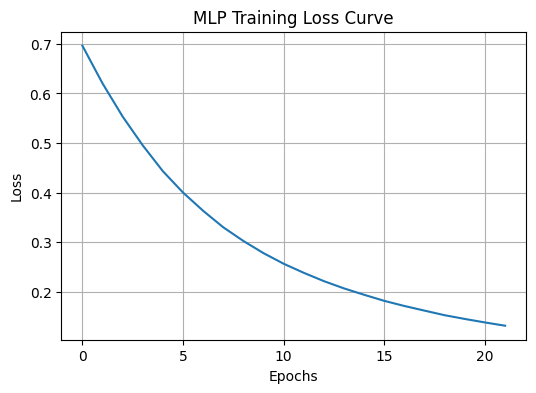

In [10]:
print(classification_report(y_val, y_val_pred, target_names=['Malignant (0)', 'Benign (1)']))  
# Print detailed classification metrics (precision, recall, F1-score) for each target class

# Plot training loss curve for educational visualization
plt.figure(figsize=(6,4))  # Set figure size for the plot
plt.plot(mlp.loss_curve_)  # Plot the training loss recorded during model fitting
plt.title('MLP Training Loss Curve')  # Add title to the plot
plt.xlabel('Epochs')  # Label X-axis as epochs (iterations)
plt.ylabel('Loss')  # Label Y-axis as loss
plt.grid(True)  # Add grid lines for better readability
plt.show()  # Display the loss curve



## Step 4 B-: Define and train the DNN model using `tensorflow`

In [11]:
import tensorflow as tf  # Import TensorFlow
from tensorflow import keras  # High-level API for deep learning
from tensorflow.keras import layers  # For defining neural network layers
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score  # For evaluation metrics
import matplotlib.pyplot as plt  # For plotting training curves
import numpy as np  # For numerical operations

print("=== Deep Neural Network (Keras) Training Summary ===\n")

# Display TensorFlow environment info
print(f"TensorFlow version: {tf.__version__}")  # Show TensorFlow version

# 1. Define the model architecture
print("Model Architecture:")  # Header for model details
print("- Input features:", X_train_scaled.shape[1])  # Number of input features
print("- Hidden layers: [64, 32]")  # Hidden layer structure
print("- Activation: ReLU for hidden layers, Sigmoid for output layer (binary classification)")  # Activations used
print("- Optimizer: Adam")  # Optimizer choice
print("- Loss function: Binary Crossentropy\n")  # Loss for binary classification

# Define a sequential model with two hidden layers
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name="Input_Layer"),  # Input layer
    layers.Dense(64, activation='relu', name="Hidden_Layer_1"),  # First hidden layer
    layers.Dense(32, activation='relu', name="Hidden_Layer_2"),  # Second hidden layer
    layers.Dense(1, activation='sigmoid', name="Output_Layer")  # Output layer for binary classification
])

=== Deep Neural Network (Keras) Training Summary ===

TensorFlow version: 2.20.0
Model Architecture:
- Input features: 30
- Hidden layers: [64, 32]
- Activation: ReLU for hidden layers, Sigmoid for output layer (binary classification)
- Optimizer: Adam
- Loss function: Binary Crossentropy



In [12]:
# 2. Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Adam optimizer with learning rate
    loss='binary_crossentropy',  # Binary crossentropy loss
    metrics=['accuracy']  # Track accuracy during training
)

# Display model summary (for educational clarity)
print("=== Model Summary ===")
model.summary()  # Print model architecture and parameters


=== Model Summary ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 3. Train the model
print("\n=== Training Progress ===")
history = model.fit(
    X_train_scaled, y_train,  # Training data
    validation_data=(X_val_scaled, y_val),  # Validation data
    epochs=10,  # Number of epochs
    batch_size=32,  # Mini-batch size
    verbose=1  # Show training output
)


=== Training Progress ===
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6978 - loss: 0.6275 - val_accuracy: 0.9011 - val_loss: 0.4482
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.3616 - val_accuracy: 0.9451 - val_loss: 0.2893
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9478 - loss: 0.2401 - val_accuracy: 0.9560 - val_loss: 0.2095
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9505 - loss: 0.1754 - val_accuracy: 0.9560 - val_loss: 0.1613
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9588 - loss: 0.1373 - val_accuracy: 0.9560 - val_loss: 0.1331
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9725 - loss: 0.1118 - val_accuracy: 0.9670 - val_loss: 0.1156
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9725 - loss: 0.0943 - val_accuracy: 0.9670 - val_loss: 0.1048
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9835 - loss: 0.0811 - val_

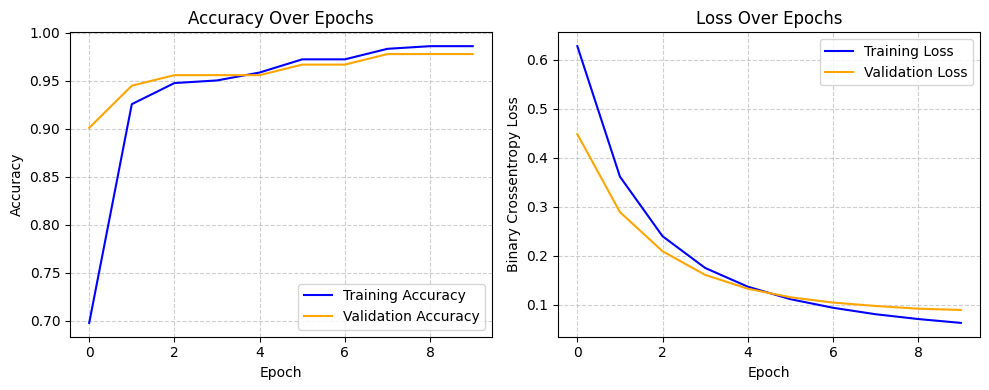

In [14]:
# 4. Visualize training vs validation accuracy and loss
plt.figure(figsize=(10, 4))  # Set figure size for side-by-side plots

# Accuracy curve
plt.subplot(1, 2, 1)  # Left plot for accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')  # Plot validation accuracy
plt.title("Accuracy Over Epochs")  # Add title
plt.xlabel("Epoch")  # X-axis label
plt.ylabel("Accuracy")  # Y-axis label
plt.legend()  # Show legend
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid lines


# Loss curve
plt.subplot(1, 2, 2)  # Right plot for loss
plt.plot(history.history['loss'], label='Training Loss', color='blue')  # Plot training loss
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')  # Plot validation loss
plt.title("Loss Over Epochs")  # Add title
plt.xlabel("Epoch")  # X-axis label
plt.ylabel("Binary Crossentropy Loss")  # Y-axis label
plt.legend()  # Show legend
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid lines

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display both plots



## Step 5: Evaluate model performance on test data

=== Evaluating Model Performance on the Test Set ===

▶ Scikit-learn MLPClassifier Results:

Test Accuracy (Scikit-learn): 0.9211

Classification Report (Scikit-learn):
               precision    recall  f1-score   support

Malignant (0)       0.90      0.88      0.89        42
   Benign (1)       0.93      0.94      0.94        72

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114


▶ TensorFlow / Keras Model Results:

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy (TensorFlow): 0.9737

Classification Report (TensorFlow):
               precision    recall  f1-score   support

Malignant (0)       0.95      0.98      0.96        42
   Benign (1)       0.99      0.97      0.98        72

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



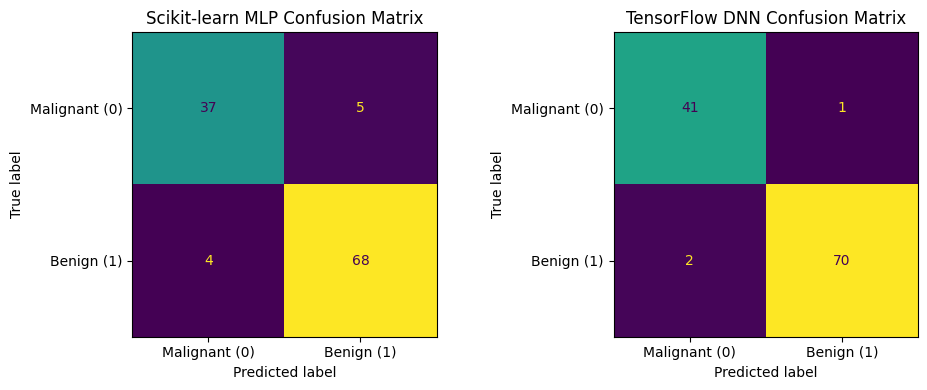


=== Comparison Summary ===
Scikit-learn MLPClassifier Accuracy: 0.9211
TensorFlow / Keras DNN Accuracy:    0.9737
➡ TensorFlow DNN slightly outperforms Scikit-learn MLP.


In [15]:
# ============================================================
# Step 5: Evaluate Model Performance on Test Data (Sklearn & TensorFlow)
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # Import metrics
import matplotlib.pyplot as plt  # For visualizing confusion matrices

print("=== Evaluating Model Performance on the Test Set ===\n")  # Header for evaluation stage

# ---------------------------
# Evaluate Scikit-learn MLP
# ---------------------------
print("▶ Scikit-learn MLPClassifier Results:\n")
y_test_pred_sklearn = mlp.predict(X_test_scaled)  # Predict test labels using trained MLPClassifier
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)  # Compute accuracy on test set
print(f"Test Accuracy (Scikit-learn): {test_acc_sklearn:.4f}\n")  # Display test accuracy
print("Classification Report (Scikit-learn):")  # Header for detailed metrics
print(classification_report(y_test, y_test_pred_sklearn, target_names=['Malignant (0)', 'Benign (1)']))  # Print precision, recall, F1

# ---------------------------
# Evaluate TensorFlow / Keras Model
# ---------------------------
print("\n▶ TensorFlow / Keras Model Results:\n")
y_test_pred_probs_tf = model.predict(X_test_scaled).ravel()  # Predict probabilities using Keras DNN
y_test_pred_tf = (y_test_pred_probs_tf > 0.5).astype(int)  # Convert probabilities to binary class predictions

test_acc_tf = accuracy_score(y_test, y_test_pred_tf)  # Calculate test accuracy
print(f"Test Accuracy (TensorFlow): {test_acc_tf:.4f}\n")  # Print test accuracy
print("Classification Report (TensorFlow):")  # Header for TensorFlow metrics
print(classification_report(y_test, y_test_pred_tf, target_names=['Malignant (0)', 'Benign (1)']))  # Display report

# ---------------------------
# Confusion Matrices Side by Side
# ---------------------------
cm_sklearn = confusion_matrix(y_test, y_test_pred_sklearn)  # Create confusion matrix for sklearn model
cm_tf = confusion_matrix(y_test, y_test_pred_tf)  # Create confusion matrix for TensorFlow model

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Create two side-by-side subplots

# Plot confusion matrix for sklearn model
ConfusionMatrixDisplay(cm_sklearn, display_labels=['Malignant (0)', 'Benign (1)']).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Scikit-learn MLP Confusion Matrix")  # Add title to first plot

# Plot confusion matrix for TensorFlow model
ConfusionMatrixDisplay(cm_tf, display_labels=['Malignant (0)', 'Benign (1)']).plot(ax=axes[1], colorbar=False)
axes[1].set_title("TensorFlow DNN Confusion Matrix")  # Add title to second plot

plt.tight_layout()  # Adjust layout spacing
plt.show()  # Display both confusion matrices

# ---------------------------
# Comparison Summary
# ---------------------------
print("\n=== Comparison Summary ===")  # Header for summary
print(f"Scikit-learn MLPClassifier Accuracy: {test_acc_sklearn:.4f}")  # Print sklearn accuracy
print(f"TensorFlow / Keras DNN Accuracy:    {test_acc_tf:.4f}")  # Print TensorFlow accuracy

# Compare which model performs better
if abs(test_acc_sklearn - test_acc_tf) < 0.01:
    print("➡ Both models perform similarly.")  # If accuracy difference < 1%
elif test_acc_sklearn > test_acc_tf:
    print("➡ Scikit-learn MLP slightly outperforms TensorFlow on this dataset.")  # Sklearn better
else:
    print("➡ TensorFlow DNN slightly outperforms Scikit-learn MLP.")  # TensorFlow better



## Step : Save model and scaler

In [16]:

import joblib
import os

# Create directory to store models
os.makedirs("saved_models", exist_ok=True)

# --- Save Scikit-learn model and scaler ---
joblib.dump(mlp, "saved_models/mlp_breast_cancer.joblib")
joblib.dump(scaler, "saved_models/scaler_breast_cancer.joblib")

print(" Scikit-learn model and scaler saved successfully.")
print("Files:")
print("- saved_models/mlp_breast_cancer.joblib")
print("- saved_models/scaler_breast_cancer.joblib\n")

# --- Save TensorFlow / Keras model ---
model.save("saved_models/keras_breast_cancer_model.h5")
print(" TensorFlow / Keras model saved successfully.")
print("File: saved_models/keras_breast_cancer_model.h5\n")

print("You can later reload them using:")
print("• joblib.load('saved_models/mlp_breast_cancer.joblib')")
print("• keras.models.load_model('saved_models/keras_breast_cancer_model.h5')")


 Scikit-learn model and scaler saved successfully.
Files:
- saved_models/mlp_breast_cancer.joblib
- saved_models/scaler_breast_cancer.joblib

 TensorFlow / Keras model saved successfully.
File: saved_models/keras_breast_cancer_model.h5

You can later reload them using:
• joblib.load('saved_models/mlp_breast_cancer.joblib')
• keras.models.load_model('saved_models/keras_breast_cancer_model.h5')


=== Model Reload and Inference Demo ===

Loading Scikit-learn model and scaler...
 Scikit-learn model successfully loaded.

Loading TensorFlow / Keras model...
 TensorFlow / Keras model successfully loaded.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
=== Inference Results on Random Test Samples ===

          True Label  Scikit-learn Prediction  TensorFlow Prediction  \
Sample 1           1                        1                      1   
Sample 2           0                        0                      0   
Sample 3           1                        1                      1   
Sample 4           1                        1                      1   
Sample 5           1                        1                      1   

          TensorFlow Probability  
Sample 1                  0.6166  
Sample 2                  0.0024  
Sample 3                  0.9984  
Sample 4                  0.9980  
Sample 5                  0.9992  

Note: 0 = Malignant, 1 = Benign



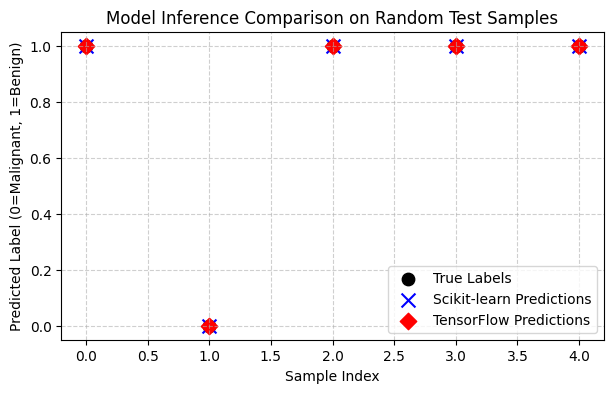

 Inference complete! The plot and table above show how both models perform on unseen data.


In [17]:
# ============================================================
# Step 9: Load Saved Models and Run Inference (Scikit-learn + TensorFlow)
# ============================================================

import joblib  # For loading saved scikit-learn models and scalers
from tensorflow import keras  # For loading TensorFlow / Keras models
import numpy as np  # For numerical operations
import pandas as pd  # For creating result tables
import matplotlib.pyplot as plt  # For visualizing predictions

print("=== Model Reload and Inference Demo ===\n")  # Header for the demo

# -------------------------------
# Load Scikit-learn Model + Scaler
# -------------------------------
print("Loading Scikit-learn model and scaler...")  # Notify loading start
mlp_loaded = joblib.load("saved_models/mlp_breast_cancer.joblib")  # Load trained sklearn MLP model
scaler_loaded = joblib.load("saved_models/scaler_breast_cancer.joblib")  # Load corresponding scaler
print(" Scikit-learn model successfully loaded.\n")  # Confirm load success

# -------------------------------
# Load TensorFlow Model
# -------------------------------
print("Loading TensorFlow / Keras model...")  # Notify loading start
keras_model_loaded = keras.models.load_model("saved_models/keras_breast_cancer_model.h5")  # Load Keras model from .h5 file
print(" TensorFlow / Keras model successfully loaded.\n")  # Confirm load success

# -------------------------------
# Select Random Test Samples for Inference
# -------------------------------
n_samples = 5  # Number of samples to test
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)  # Randomly select test indices
X_sample = X_test.iloc[sample_indices]  # Extract random samples from test set
y_true_sample = y_test.iloc[sample_indices].values  # Extract corresponding true labels

# Scale sample using loaded scaler
X_sample_scaled = scaler_loaded.transform(X_sample)  # Apply same scaling used during training

# -------------------------------
# Run Predictions
# -------------------------------
# Scikit-learn Predictions
y_pred_sklearn = mlp_loaded.predict(X_sample_scaled)  # Predict labels using sklearn model

# TensorFlow Predictions
y_pred_tf_probs = keras_model_loaded.predict(X_sample_scaled).ravel()  # Predict probabilities with Keras model
y_pred_tf = (y_pred_tf_probs > 0.5).astype(int)  # Convert probabilities to binary classes

# -------------------------------
# Display Results
# -------------------------------
print("=== Inference Results on Random Test Samples ===\n")  # Header for results
df_results = pd.DataFrame({  # Create a DataFrame to compare predictions
    "True Label": y_true_sample,
    "Scikit-learn Prediction": y_pred_sklearn,
    "TensorFlow Prediction": y_pred_tf,
    "TensorFlow Probability": np.round(y_pred_tf_probs, 4)
})
df_results.index = [f"Sample {i+1}" for i in range(len(df_results))]  # Label rows for readability
print(df_results)  # Print comparison table
print("\nNote: 0 = Malignant, 1 = Benign\n")  # Clarify label meaning

# -------------------------------
# Visualization of Comparison
# -------------------------------
plt.figure(figsize=(7, 4))  # Set figure size
x = np.arange(n_samples)  # X-axis positions for samples
plt.scatter(x, y_true_sample, color="black", label="True Labels", marker='o', s=80)  # Plot true labels
plt.scatter(x, y_pred_sklearn, color="blue", label="Scikit-learn Predictions", marker='x', s=100)  # Plot sklearn predictions
plt.scatter(x, y_pred_tf, color="red", label="TensorFlow Predictions", marker='D', s=70)  # Plot TensorFlow predictions
plt.title("Model Inference Comparison on Random Test Samples")  # Add title
plt.xlabel("Sample Index")  # X-axis label
plt.ylabel("Predicted Label (0=Malignant, 1=Benign)")  # Y-axis label
plt.legend()  # Show legend
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid lines
plt.show()  # Display the plot

print(" Inference complete! The plot and table above show how both models perform on unseen data.")  # Completion message
